In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


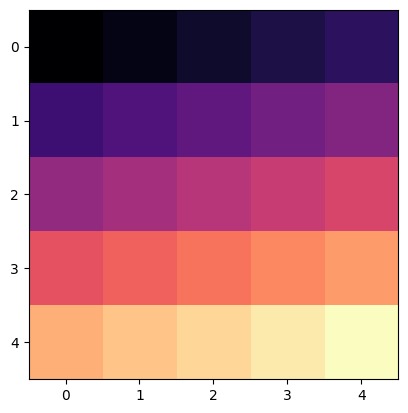

In [4]:
a= np.zeros((5, 5), dtype=np.float32)
a= np.arange(25).reshape(5, 5)
plt.imshow(a, cmap='magma') #----> 1채널 이미지


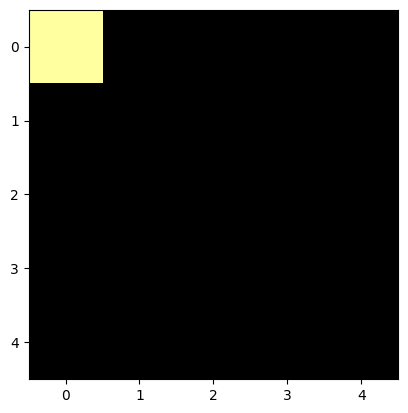

In [5]:
# 컬러 영상 H, W, 3(RGB or BGR)
image=np.zeros((5, 5, 3), dtype= np.uint8)
plt.imshow(image)

#  삭제 안 하면 색깔이 계속 쌓임====> 안 없어짐*************

image[0, 0, 0]= 255
image[0, 0, 2]= 160
image[0, 0, 1]= 255

plt.imshow(image)


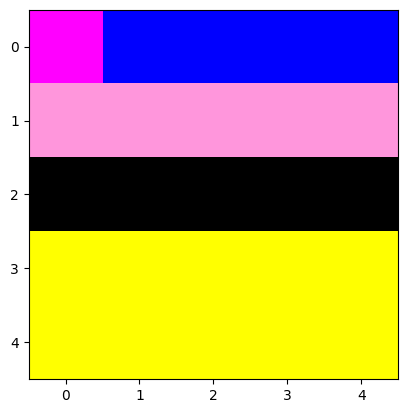

In [6]:
# 컬러 영상 H, W, 3(RGB or BGR)
image=np.zeros((5, 5, 3), dtype= np.uint8)
plt.imshow(image)

#  삭제 안 하면 색깔이 계속 쌓임====> 안 없어짐*************

image[0, 0, 0]= 255
image[0, :, 2]= 255
image[1, :]= [255, 150, 220] #shape----> 3
image[3:, :]= [255, 255, 0] 

plt.imshow(image)


In [7]:
cv2.imread('test.jpg', image)

array([[[255,   0, 255],
        [  0,   0, 255],
        [  0,   0, 255],
        [  0,   0, 255],
        [  0,   0, 255]],

       [[255, 150, 220],
        [255, 150, 220],
        [255, 150, 220],
        [255, 150, 220],
        [255, 150, 220]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[255, 255,   0],
        [255, 255,   0],
        [255, 255,   0],
        [255, 255,   0],
        [255, 255,   0]],

       [[255, 255,   0],
        [255, 255,   0],
        [255, 255,   0],
        [255, 255,   0],
        [255, 255,   0]]], dtype=uint8)

In [8]:
!curl -L "https://img.sbs.co.kr/newsnet/etv/upload/2025/12/02/30001030003_1280.jpg" -o ive.jpg

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100 225.0k 100 225.0k   0      0  1.35M      0                              0
100 225.0k 100 225.0k   0      0  1.35M      0                              0
100 225.0k 100 225.0k   0      0  1.35M      0                              0


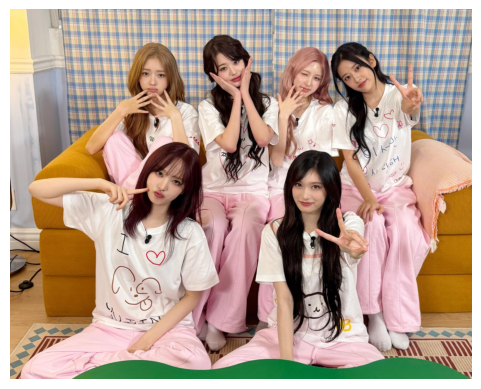

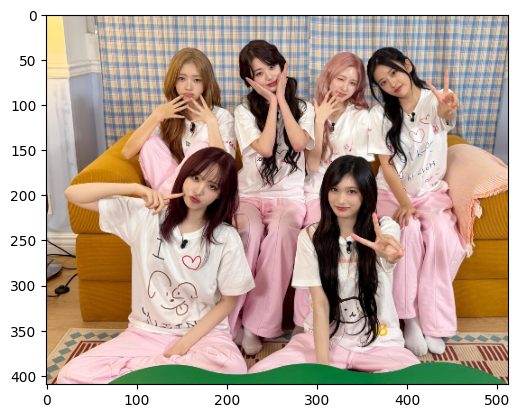

In [14]:
image=cv2.imread("ive.jpg")

plt.imshow(image)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis("off")
plt.show()

image = image[..., [2, 1, 0]]
image = cv2.resize(image, None, fx=0.4, fy=0.4)
plt.imshow(image)

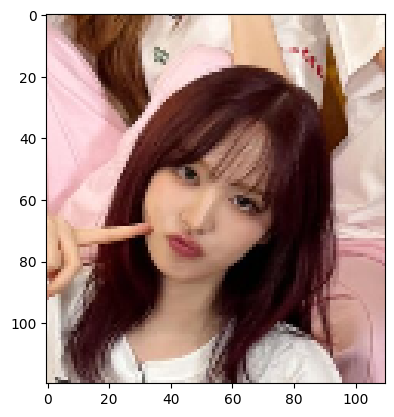

In [17]:
liz = image[130:250, 120:230]
liz

plt.imshow(liz)

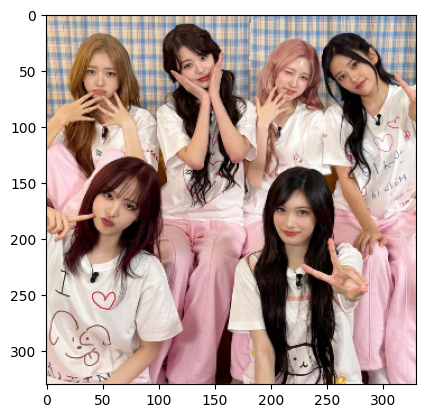

In [34]:
H, W, _ = image.shape
y1 = 20
y2 = 350
x1 = 110
x2 = 440
image[y1:y2, x1:x2]

plt.imshow(image[y1:y2, x1:x2])


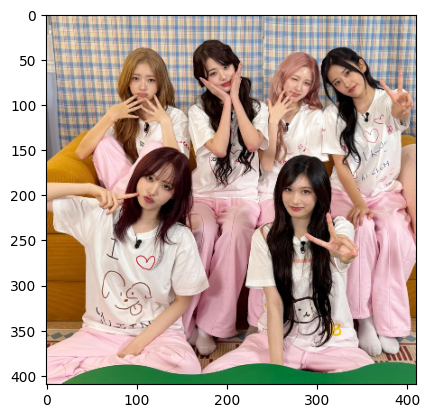

In [37]:
H, W, _ = image.shape
size = min(H, W)
y1 = (H - size) // 2
y2 = y1 + size
x1 = (W - size) // 2
x2 = x1 + size
image[y1:y2, x1:x2]

plt.imshow(image[y1:y2, x1:x2])

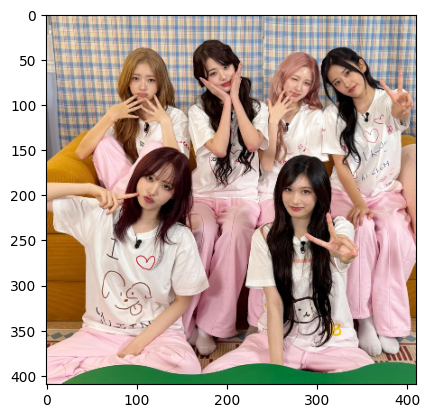

In [38]:
H, W, _ = image.shape
delta = int(abs(H - W)/2)
y1 = 0
y2 = H
x1 = delta
x2 = W - delta
image[y1:y2, x1:x2]


plt.imshow(image[y1:y2, x1:x2])

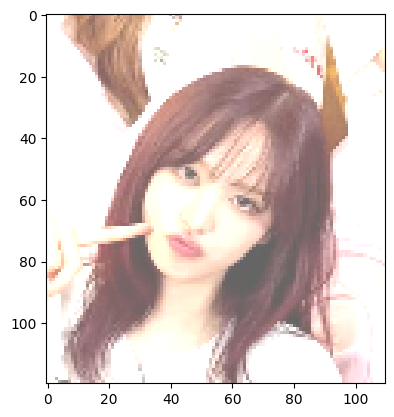

In [73]:

# 밝기(brightness) - 덧셈연산
# 대비(contrast) - 곱셈

a= np.float32(liz) +100
# a[a>255]= 255
# a[a>0]= 0
a= np.clip(a, 0, 255)
a= np.uint8(a)
plt.imshow(a)

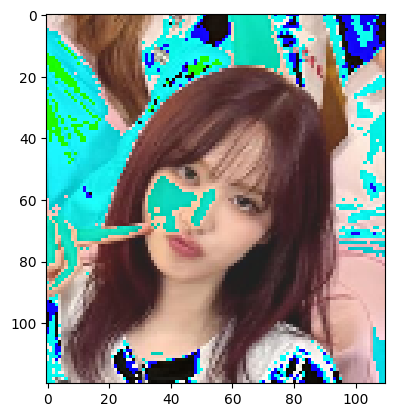

In [40]:
liz+ 30

plt.imshow(liz+30)

In [48]:
a = np.array([0, 128, 255], np.uint8)
a + 30 # overflow
a - 1 # underflow지만 보통 그냥 다 overflow

array([255, 127, 254], dtype=uint8)

연습

https://colab.research.google.com/drive/1Qxw-eSKncbJ24KBLUx72qVfAhIxWD9fG?usp=sharing

In [ ]:
# numpy(pandas) 에서 여러 개의 원소를 접근하는 3가지 방법
# - slicing (:)
# - list of index (용어??)
# - list of bool

# 1. 슬라이실
a= np.array([1, 2, 3, 4, 5])
a[:3]

# 2. 직접 지정
a([0, 3, 2])
a([0, 0, 2, 2, 1, 1]) # 중복지정 가능하고 순서도 마음대로
a[[4, 3, 2, 1, 0]] #-----> 이용해서 셔플 가능

In [70]:
import numpy as np

a = np.array([10, 11, 12, 13, 14])

i = np.random.permutation(5)

print(i)
print(a[i])
print(a[[True, False, False, True, False]])
print(a[a % 2 == 1])

[4 3 0 1 2]
[14 13 10 11 12]
[10 13]
[11 13]


IndexError: boolean index did not match indexed array along axis 0; size of axis is 6 but size of corresponding boolean axis is 5

In [60]:
# minmax scaling-> [0. 1]
a= np.array([22, 10, 32, 5, 1, 4])
M=a.max()
m=a.min()

# 정규화(----> a의 값이 위처럼 주어졌을 때, -1~1 까지의 값으로 스케일링 해라)
B= -1
T= 1
M=a.max()
m=a.min()

scaled= ((a-m)/(M-m))*(T-B) +B
print(scaled)

[ 0.35483871 -0.41935484  1.         -0.74193548 -1.         -0.80645161]


In [63]:
# minmax scaling-> [0. 1]
a= np.array([22, 10, 32, 5, 1, 4])
M=a.max()
m=a.min()

# 정규화(----> a의 값이 위처럼 주어졌을 때, -1~1 까지의 값으로 스케일링 해라)
B= -1
T= 1



In [ ]:
x= np.array([1, 3, 5, 7])
y= np.array([0, 1, 2, 3])
s= 1/2
# x[0]* s+ b= y[0]
b= -1/2
x*s+b

array([0., 1., 2., 3.])